In [32]:
import switchy.CloneStats as cs
import switchy.util as ut
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
import scanpy.external as sce
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }
from nheatmap import nhm
mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/8.30.20_PaperDraft/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# Load SJout Data
ab_tx, switch_tx = ut.loadSJoutIGH('../../../SharedData/SJ/CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


In [34]:
ab_tx

,level_0,index,chrom,start,end,strand,intron_motif,annotated,unique_mapping,multi_mapping,max_overhang,cell,SAMPLE,J_exon,exon_start,exon_simple
10,913,8158,14,105601520,105865406,2,2,1,9,6,49,PASL_2_PA_11_plate_1_D11,Donor_11,IGHJ1,105601520,105601520
18,921,8166,14,105601728,105863197,2,2,1,4,335,43,PASL_2_PA_11_plate_1_D11,Donor_11,IGHJ6,IGHE_exon1_5prime,IGHE
19,922,8167,14,105601728,105863813,2,2,1,67,629,48,PASL_2_PA_11_plate_1_D11,Donor_11,IGHJ5,IGHE_exon1_5prime,IGHE
20,923,8168,14,105601728,105864214,2,2,1,3,492,49,PASL_2_PA_11_plate_1_D11,Donor_11,IGHJ4,IGHE_exon1_5prime,IGHE
21,924,8169,14,105601728,105865198,2,2,1,989,635,69,PASL_2_PA_11_plate_1_D11,Donor_11,IGHJ2,IGHE_exon1_5prime,IGHE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239168,1786580,3745615,14,105708665,105863813,2,2,1,3,23020,43,B107914_A20,SS2,IGHJ5,IGHA1_exon1_5prime,IGHA1
239169,1786581,3745616,14,105708665,105864214,2,2,1,25868,26171,46,B107914_A20,SS2,IGHJ4,IGHA1_exon1_5prime,IGHA1
239170,1786582,3745617,14,105708665,105865198,2,2,1,385,5842,31,B107914_A20,SS2,IGHJ2,IGHA1_exon1_5prime,IGHA1
239171,1786583,3745618,14,105708665,105865406,2,2,1,15,12706,37,B107914_A20,SS2,IGHJ1,IGHA1_exon1_5prime,IGHA1


In [52]:
adata = sc.read_h5ad('../data/CombinedDivisionImmcantation.h5ad')

In [53]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.filter_cells(adata, min_counts=50000)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.sqrt(adata)

In [54]:
def imputeGenes(adata, genes):
    adata_magic = sce.pp.magic(adata, name_list=genes, knn=5)
    

    array = adata_magic.X

    adata_magic.obs.index

    df = pd.DataFrame(array)

    df.index = adata_magic.obs.index

    df.columns = adata_magic.var.index
    
    return df

In [55]:
IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']


In [56]:
df = imputeGenes(adata, IgH_genes)

In [57]:
df

,IGHA2,IGHE,IGHG4,IGHG2,IGHG1,IGHA1,IGHG3,IGHD,IGHM
cell,,,,,,,,,
CTY_I8,0.324681,13.046625,3.091221,3.602514,5.587841,1.042345,19.144279,8.840422,39.311211
MS_SISTER2_J10,0.005687,8.204885,1.682434,0.728006,2.923868,0.057260,12.431087,7.142170,22.898241
NaiveBcellsplate2_20180629_D23,0.205145,0.271535,0.106099,0.905480,0.714444,1.123152,1.194885,34.475613,72.556541
NaiveBcellsplate2_20180629_K4,0.217721,0.353889,0.077168,0.819438,0.707475,1.258158,0.835518,34.761082,70.185814
NaiveBcellsplate2_20180629_P1,0.335925,0.722173,0.052857,0.599557,0.543530,1.648343,0.797854,34.226341,74.823769
...,...,...,...,...,...,...,...,...,...
P1_5_23_19_D2_H8,0.770408,29.383392,7.241397,10.346794,23.342018,11.258415,30.548071,1.010789,56.630177
P1_5_23_19_D2_A19,0.597152,29.367243,4.672662,5.510722,17.761724,12.299495,24.250278,1.708323,73.959320
P1_5_23_19_D2_M5,0.963685,18.146118,4.360698,16.510881,27.086685,7.861499,24.666801,0.680620,98.473587


df = ut.getCellByGeneMatrix(adata)

In [40]:
# Filter Sjout to be only cells which pass QC
ab_tx = ab_tx[ab_tx.cell.isin(adata.obs.index)]

switch_tx = switch_tx[switch_tx.cell.isin(adata.obs.index)]

switch_tx['exon_start'] = switch_tx['exon_start'].str.split('_', expand = True)[0]
ab_tx['exon_start'] = ab_tx['exon_start'].str.split('_', expand = True)[0]

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


In [41]:
def clustermap(df):
    sum_df = df.groupby(['cell', 'exon_start']).sum()
    sum_df['uniquelog2'] = np.log10(sum_df['unique_mapping'])
    ret_df = sum_df.uniquelog2.unstack().fillna(np.log10(1))
    ret_df = ret_df[IgH_genes]
    sns.clustermap(ret_df)
    return ret_df

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/seaborn/matrix.py:649: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


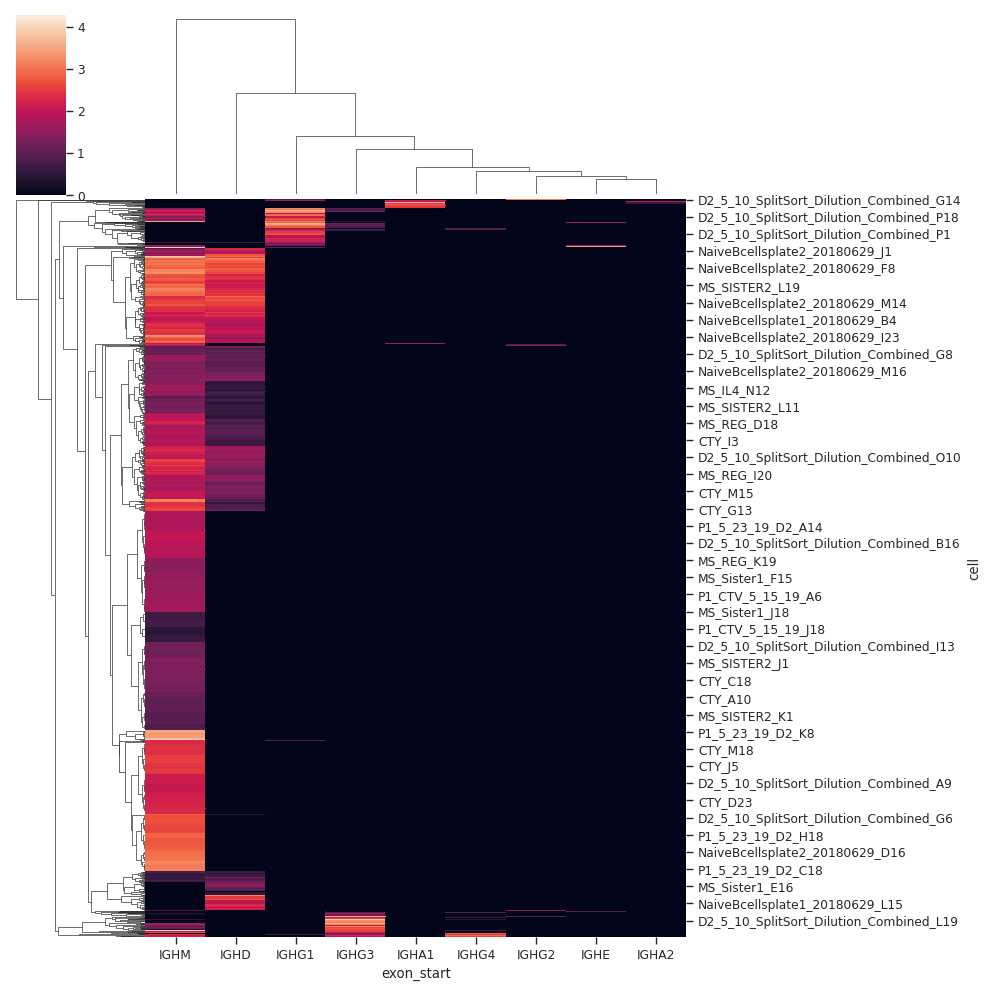

In [42]:
cellbygeneAb = clustermap(ab_tx)

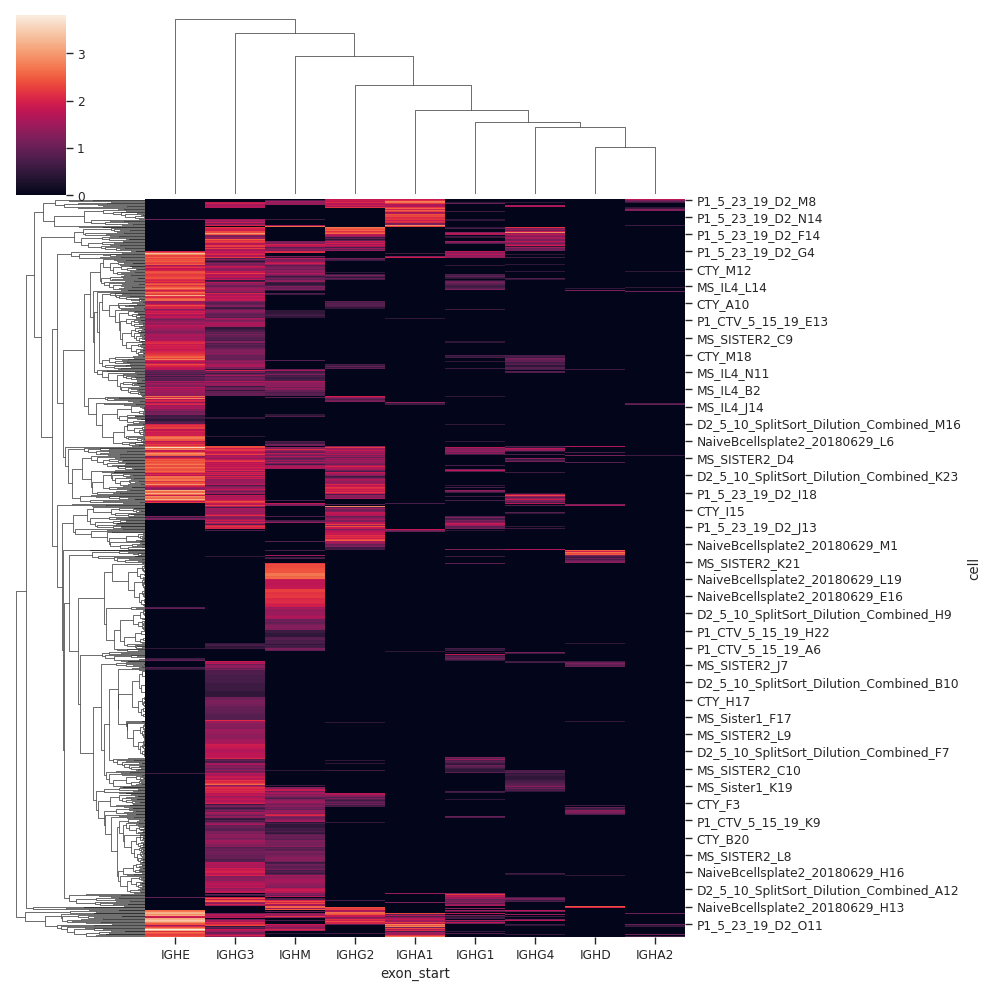

In [43]:
cellbygeneSwitch = clustermap(switch_tx)

In [44]:
def clean_df(dataframe):
    columns = dataframe.columns.to_list()
    rows = dataframe.index.to_list()
    return pd.DataFrame(data = dataframe.values, index=rows, columns=columns)

In [45]:
ab = clean_df(cellbygeneAb)

In [58]:
dfr = adata.obs[['Treatment', 'Division_Number', 'ISOTYPE']]
dfr.columns = ['Treatment', 'Division Number', 'Isotype']
_dfr = clean_df(dfr)
_dfr['Division Number'] = _dfr['Division Number'].replace('None', '0')
_dfr = _dfr[_dfr.Isotype.isin(IgH_genes)]
_df = df[df.index.isin(_dfr.index)]

In [59]:
cmaps={'Treatment':'Set1', 'PC1':'RdYlGn', 'gene cluster':'inferno',
        'Division Number':'Reds', 'Isotype':'Paired'}

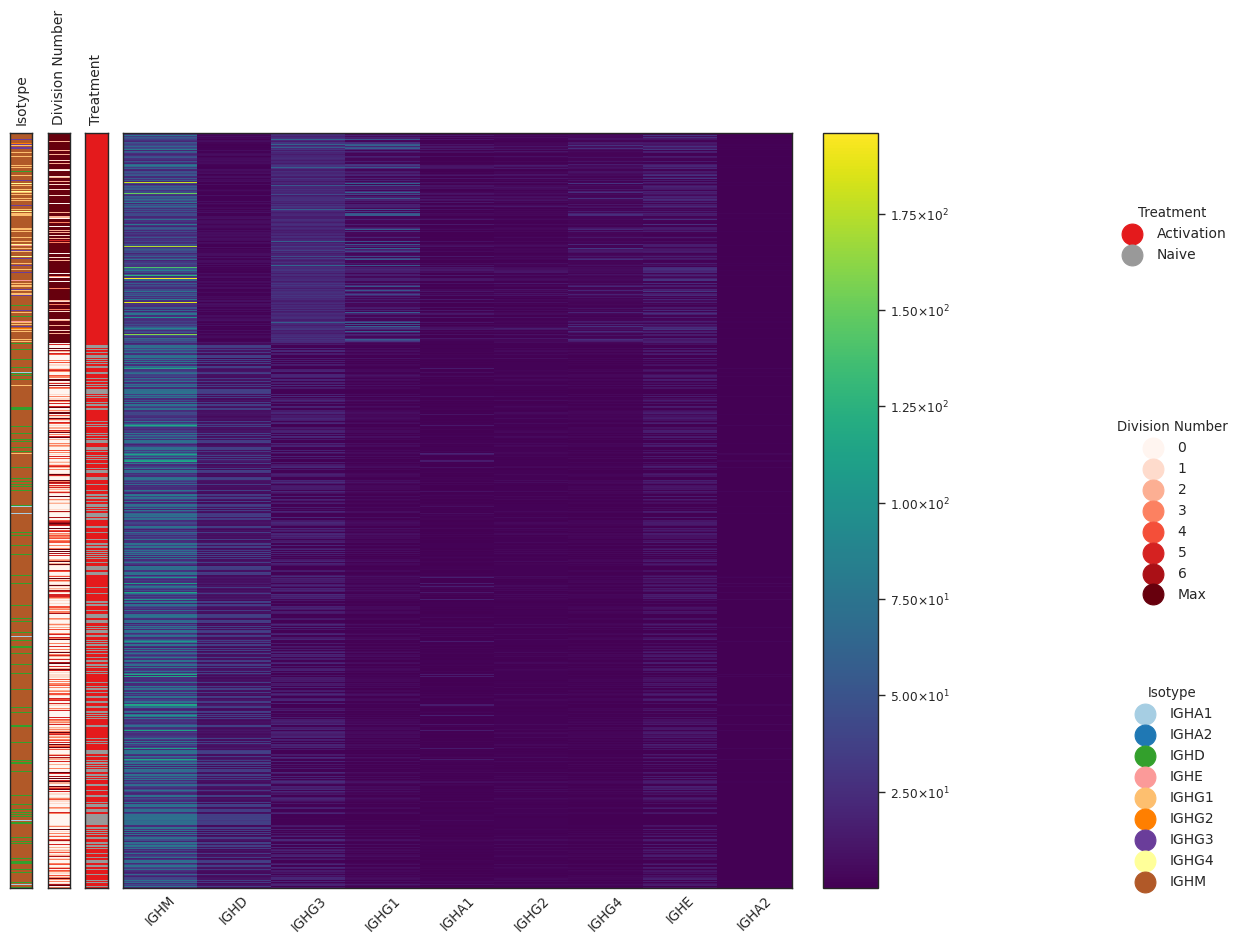

In [60]:
g = nhm(data=_df[IgH_genes], dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90)
fig, plots = g.run()

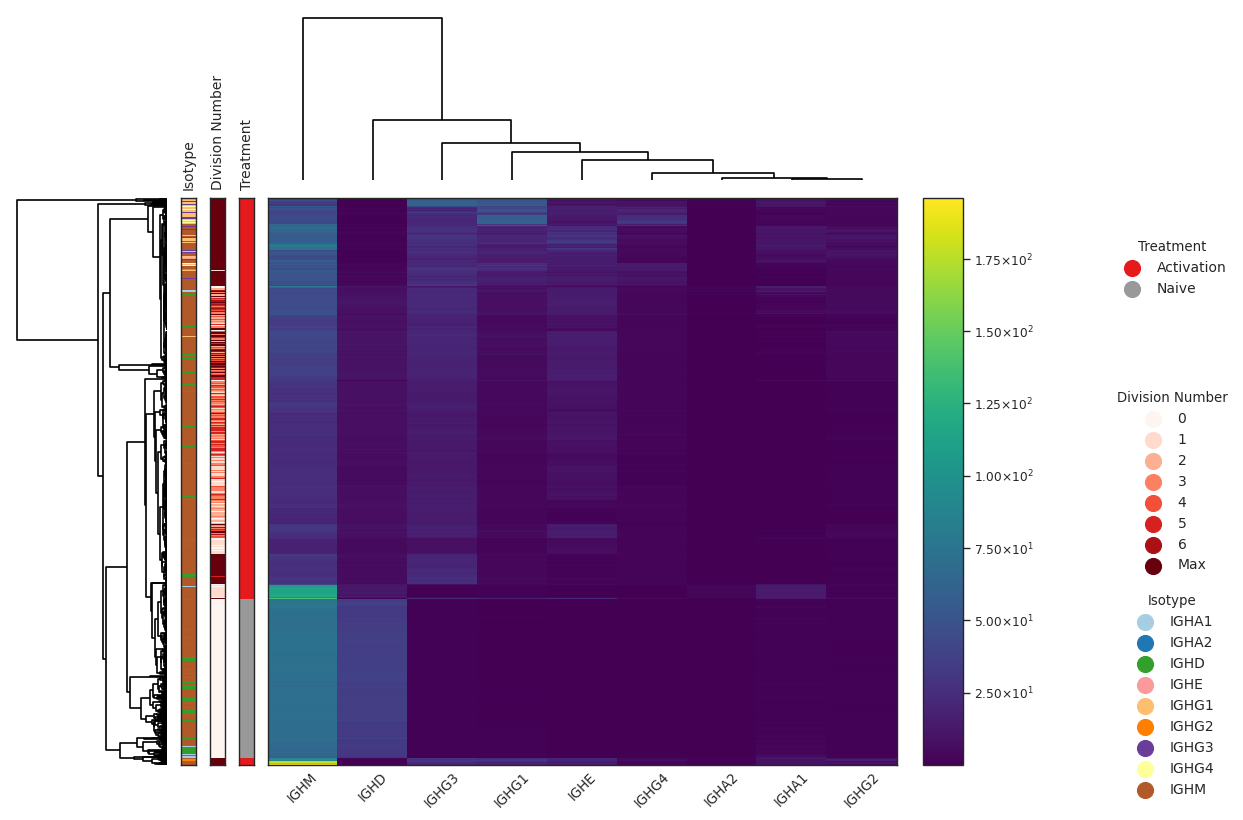

In [61]:
g.hcluster()
fig, plots = g.run()

In [18]:
save_figure(fig, 'nheatmapIgH')

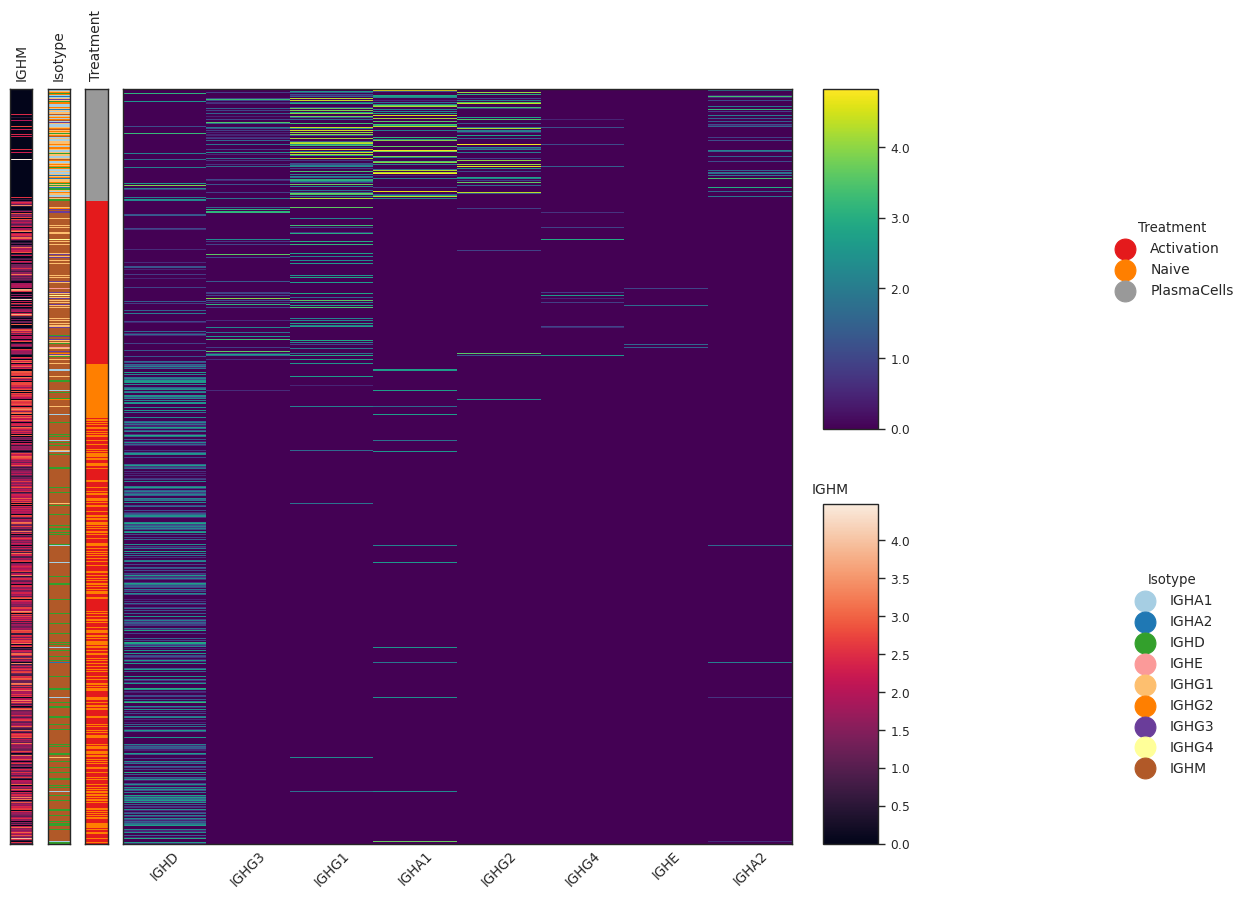

In [19]:
_df = cellbygeneAb

_df = pd.merge(_dfr, _df, left_index=True, right_index=True)

_dfr = _df.iloc[:,:3]
data = _df.iloc[:,3:]

g = nhm(data=data, dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90, )
fig, plots = g.run()

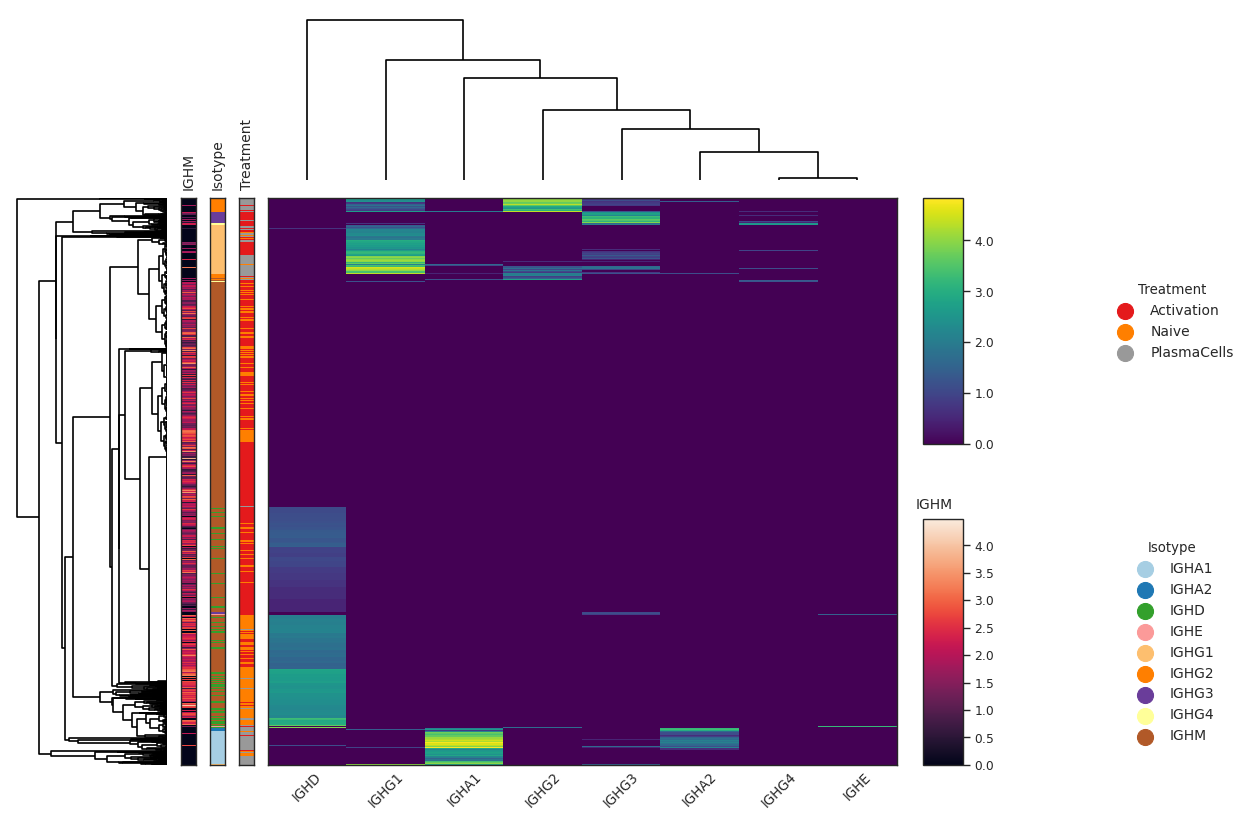

In [20]:
g.hcluster()
fig, plots = g.run()

In [21]:
save_figure(fig, "AbTx_nheatmap")

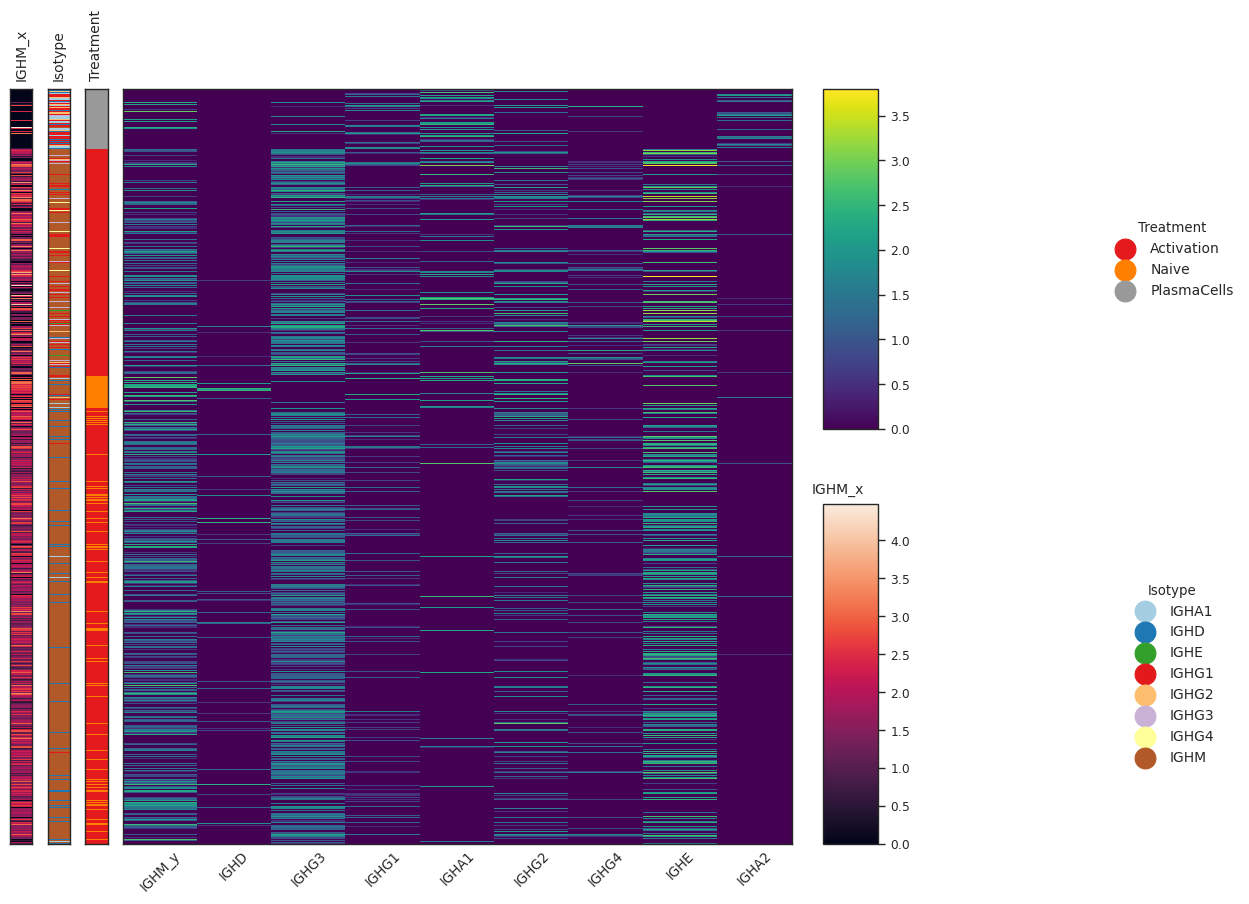

In [22]:
_df = cellbygeneSwitch

_df = pd.merge(_dfr, _df, left_index=True, right_index=True)

_dfr = _df.iloc[:,:3]
data = _df.iloc[:,3:]

g = nhm(data=data, dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90, )
fig, plots = g.run()

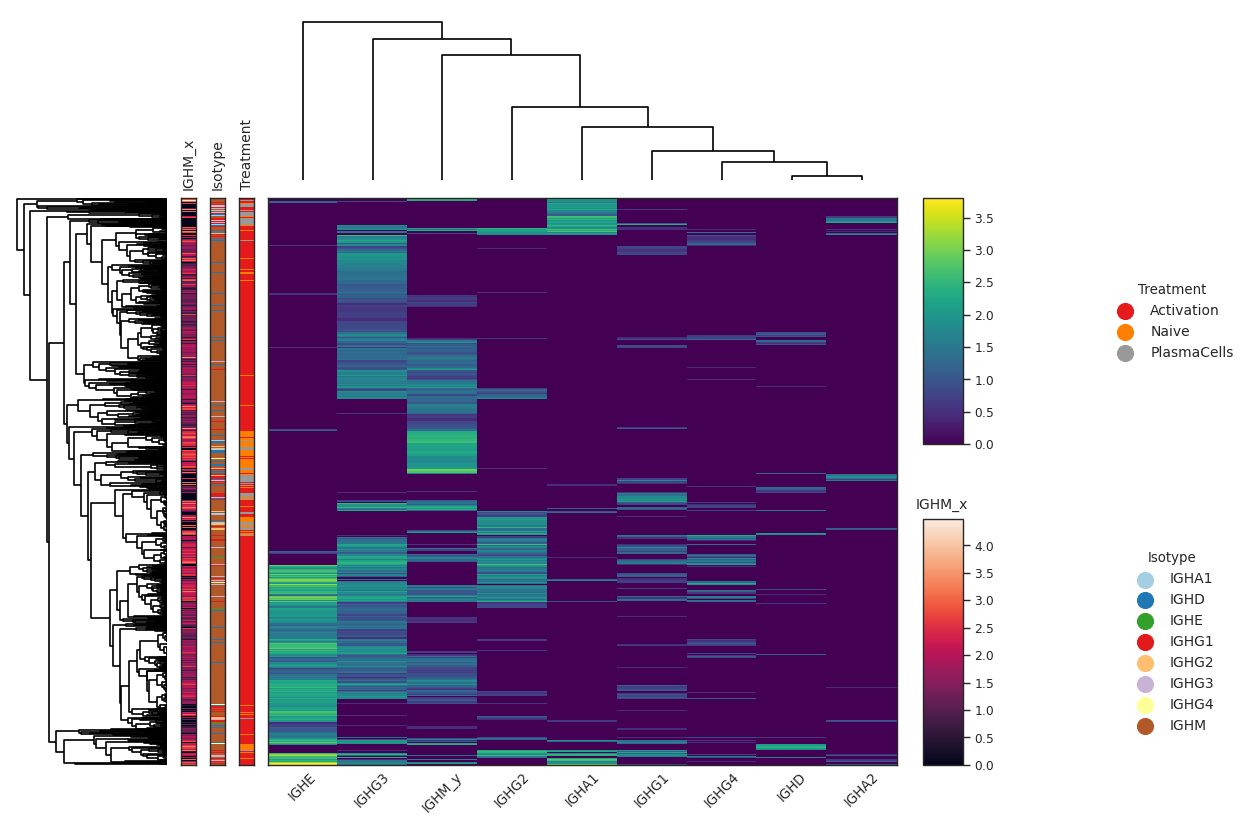

In [23]:
g.hcluster()
fig, plots = g.run()

In [24]:
save_figure(fig, "SwitchTX_NHeatMap")